In [ ]:
# Dataset Link
# https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Wholesale customers data.csv')
X = dataset.iloc[:, 2:].to_numpy()
dataset

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

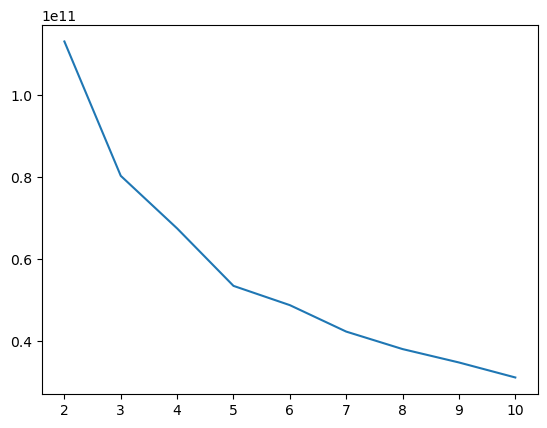

In [3]:
from sklearn.cluster import KMeans

wcss = []
for i in range(2,11):
    kmeans = KMeans(i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss)
plt.show()

d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

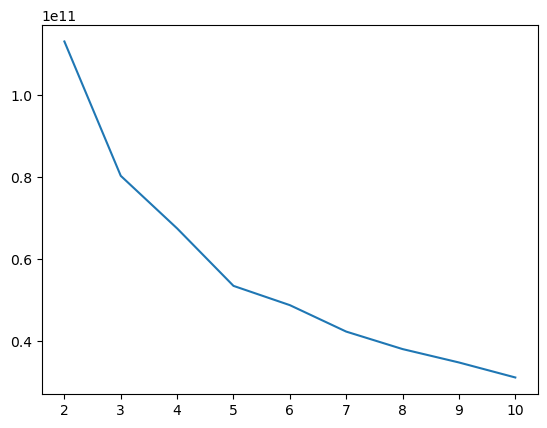

In [4]:
from sklearn.metrics import silhouette_score

scores = []
for i in range(2,11):
    kmeans = KMeans(i, random_state=0)
    pred = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, pred))

plt.plot(range(2,11), wcss)
plt.show()

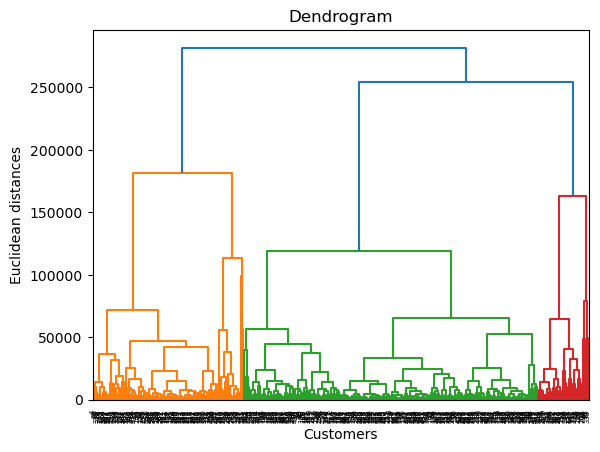

In [5]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [6]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

d:\Program_Files\miniconda3\envs\pt_gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


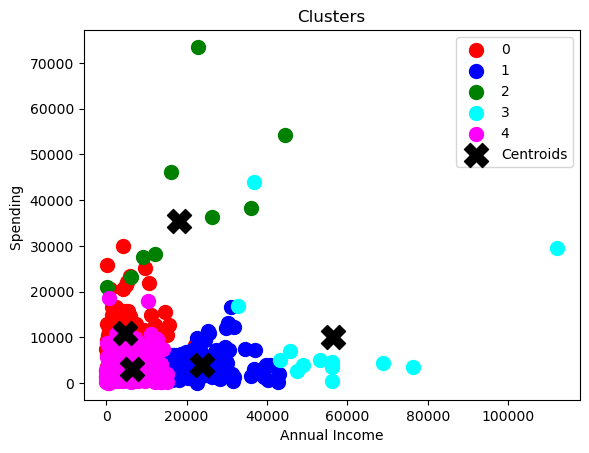

In [ ]:
colors = ["red", "blue", "green", "cyan", "magenta"]


for i in range(5):
    plt.scatter(
        X[:, 0][y_kmeans == i],
        X[:, 1][y_kmeans == i],
        s=100   ,
        c=colors[i],
        label=i,
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="black",
    label="Centroids",
)

plt.title("Clusters")
plt.xlabel("Annual Income")
plt.ylabel("Spending ")
plt.legend()
plt.show()